In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [6]:
df = pd.read_csv('data/cellref_combined_results_all_cells.csv', index_col=0)
df.head()

,cellref_true,azimuth_pred,azimuth_score,celltypist_pred,celltypist_score,frmatch_pred,frmatch_score,scarches_pred,scarches_score
001C_AAACCTGTCAACACCA,Alveolar macrophage,Alveolar macrophages,1.000000,Alveolar macrophages,0.802325,Alveolar macrophages,0.132496,Alveolar macrophages,0.919998
001C_AAACCTGTCACAGTAC,Natural killer cell,CD8 T cells,0.572845,NK cells,0.573364,NK cells,1.000000,CD8 T cells,0.719992
001C_AAACGGGAGACTAAGT,Lymphatic endothelial cell,Lymphatic EC differentiating,0.581600,Lymphatic EC mature,0.584408,Lymphatic EC mature,1.000000,Lymphatic EC mature,0.779976
001C_AAACGGGAGGGAACGG,Inflammatory monocyte,Classical monocytes,1.000000,Classical monocytes,0.903436,Classical monocytes,0.358062,Classical monocytes,1.000000
001C_AAACGGGCAGTAGAGC,Inflammatory monocyte,Classical monocytes,0.350272,Monocyte-derived Mph,0.718757,Classical monocytes,0.798721,Classical monocytes,0.840009


# Cluster Size Plot

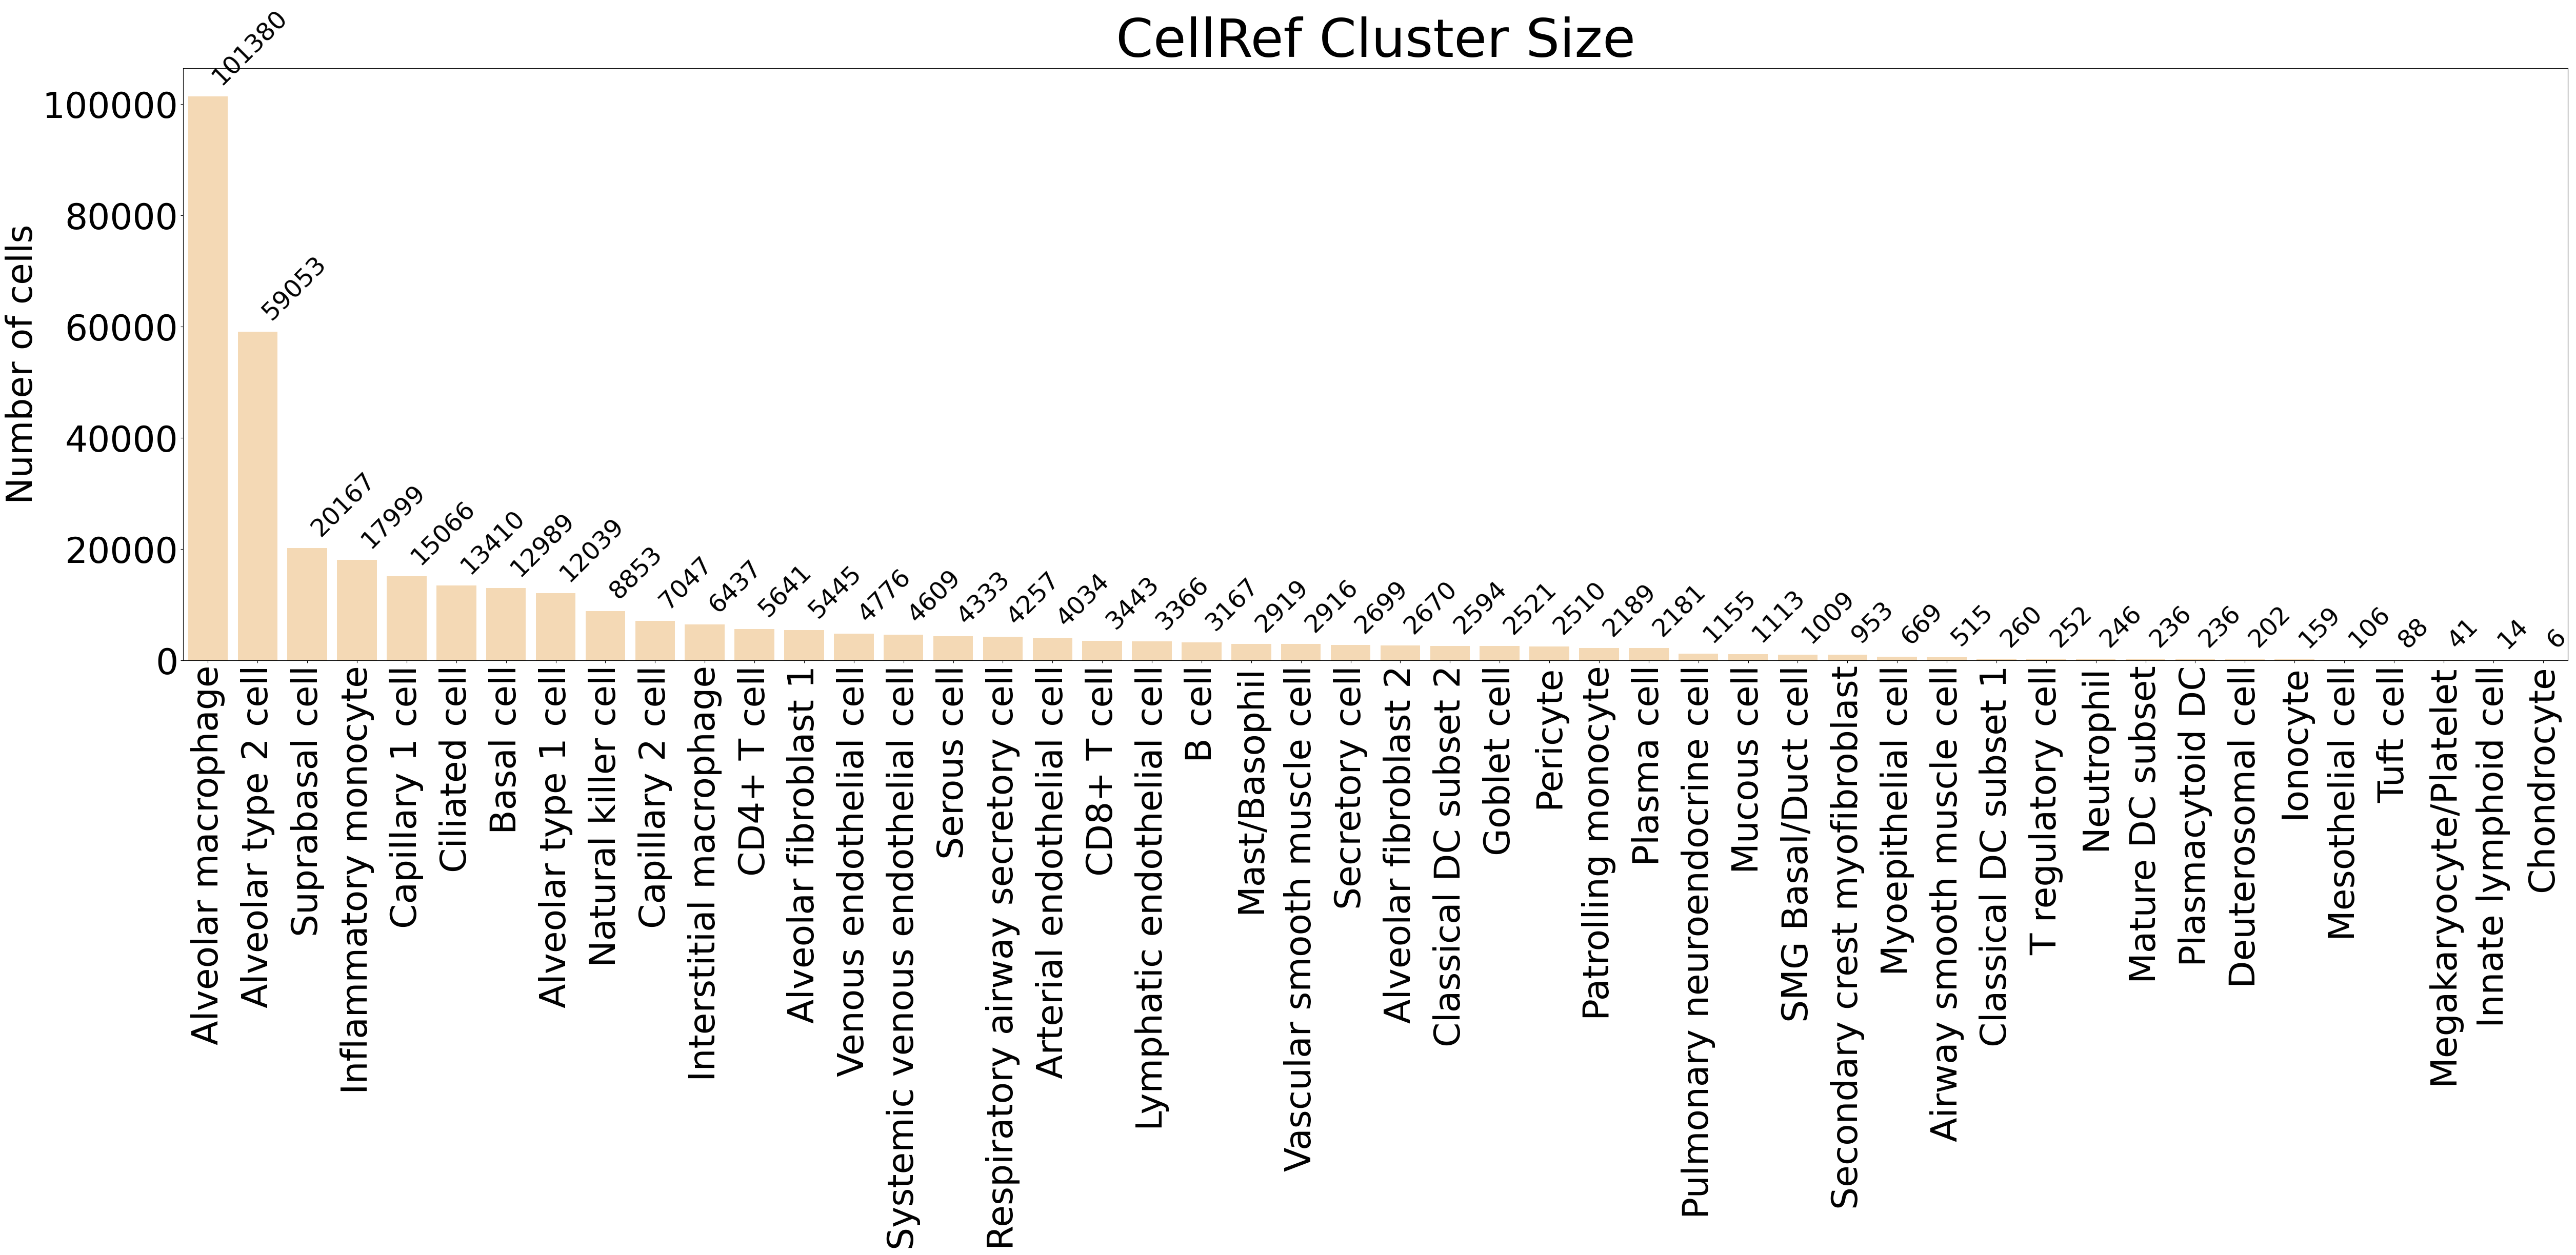

In [23]:
plt.figure(figsize=(60, 15))
ax = sns.barplot(df['cellref_true'].value_counts(), color='#FFDBAA')
ax.set_xlabel('')
ax.set_ylabel('Number of cells', fontsize=50)
plt.xticks(rotation=90, fontsize=50)
ax.tick_params(axis='y', which='major', labelsize=50)
for p in ax.patches:
    ax.annotate(format(int(p.get_height()), 'd'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'left', va = 'bottom', 
                xytext = (0, 10), rotation=45,
                textcoords = 'offset points',
                fontsize=35)
    
plt.title('CellRef Cluster Size', fontsize=75)
plt.show()

# Max Agreement Plot

In [94]:
def num_agree(row):
    
    # get predictions
    preds = row[['azimuth_pred', 'celltypist_pred', 'fr-match_pred', 'scarches_pred']]
    
    # return the maximum count of any value in the predictions
    return preds.value_counts().max()

# test case
test = pd.DataFrame([['a', 'b', 'c', 'd'], ['a', 'a', 'b', 'b'], ['a', 'a', 'a', 'd'], 
                     ['a', 'a', 'a', np.nan], ['a', 'a', 'a', 'a']], 
            columns = ['azimuth_pred', 'celltypist_pred', 'fr-match_pred','scarches_pred'])

# should be 1, 2, 3, 3, 4
test.apply(lambda row: num_agree(row), axis=1)

0    1
1    2
2    3
3    3
4    4
dtype: int64

In [95]:
df['max_agreement'] = df.apply(lambda row: num_agree(row), axis=1)
df

,cellref_true,azimuth_pred,azimuth_score,celltypist_pred,celltypist_score,fr-match_pred,fr-match_score,scarches_pred,scarches_score,max_agreement
001C_AAACCTGTCAACACCA,Alveolar macrophage,Alveolar macrophages,1.000000,Alveolar macrophages,0.802325,Alveolar macrophages,0.132496,Alveolar macrophages,0.919998,4
001C_AAACCTGTCACAGTAC,Natural killer cell,CD8 T cells,0.572845,NK cells,0.573364,NK cells,1.000000,CD8 T cells,0.719992,2
001C_AAACGGGAGACTAAGT,Lymphatic endothelial cell,Lymphatic EC differentiating,0.581600,Lymphatic EC mature,0.584408,Lymphatic EC mature,1.000000,Lymphatic EC mature,0.779976,3
001C_AAACGGGAGGGAACGG,Inflammatory monocyte,Classical monocytes,1.000000,Classical monocytes,0.903436,Classical monocytes,0.358062,Classical monocytes,1.000000,4
001C_AAACGGGCAGTAGAGC,Inflammatory monocyte,Classical monocytes,0.350272,Monocyte-derived Mph,0.718757,Classical monocytes,0.798721,Classical monocytes,0.840009,3
...,...,...,...,...,...,...,...,...,...,...
TTTGTTGTCCGGACTG-1_6,Plasma cell,B cells,0.483221,Plasma cells,0.854837,Plasma cells,1.000000,Plasma cells,0.679949,3
TTTGTTGTCGACGATT-1_5,Mast/Basophil,B cells,0.880783,Mast cells,0.970443,Mast cells,1.000000,CD8 T cells,0.399941,2
TTTGTTGTCGGTATGT-1_7,Interstitial macrophage,DC2,0.594327,Interstitial Mph perivascular,0.127694,Interstitial Mph perivascular,0.368185,Non-classical monocytes,0.359996,2
TTTGTTGTCGTCACCT-1_7,Alveolar type 2 cell,AT2,0.724512,AT2,0.096348,AT2,1.000000,AT2,0.940002,4


In [96]:
cluster_order = df['cellref_true'].value_counts().index

In [97]:
colors = sns.color_palette("coolwarm", as_cmap=False, n_colors=4).as_hex()
print(colors)

['#7b9ff9', '#c0d4f5', '#f2cbb7', '#ee8468']


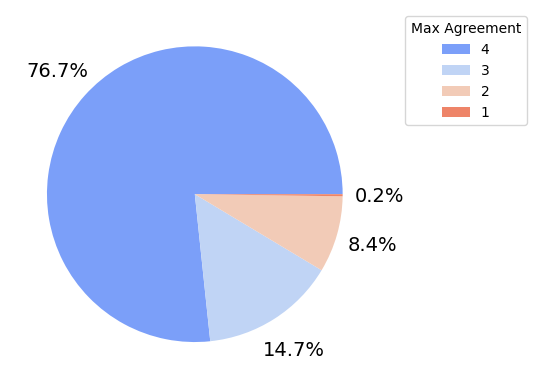

In [106]:
#colors = ['#ED9455', '#FFBB70', '#FFEC9E', '#FFFBDA']
#colors = ['#006769', '#40A578', '#9DDE8B', '#E6FF94']
#colors = ['#8FB1E9','#A9D7F6','#F96D6D','#B84D69']
plt.pie(df['max_agreement'].value_counts(), colors=colors,
        autopct='%1.1f%%', pctdistance=1.25, labeldistance=0.6,
        textprops={'fontsize': 14})

plt.legend(labels=df['max_agreement'].value_counts().index, 
           title='Max Agreement', bbox_to_anchor=(1.05, 1), loc='upper left')


In [99]:
new_df = pd.crosstab(df['cellref_true'], df['max_agreement'])
new_df = new_df.div(new_df.sum(axis=1), axis=0)
new_df = new_df.reindex(cluster_order)
new_df = new_df.reindex([4, 3, 2, 1], axis=1)

new_df

max_agreement,4,3,2,1
Alveolar macrophage,0.780736,0.134819,0.084415,0.000030
Alveolar type 2 cell,0.983777,0.012328,0.003861,0.000034
Suprabasal cell,0.840036,0.153369,0.006496,0.000099
Inflammatory monocyte,0.473915,0.339130,0.181121,0.005834
Capillary 1 cell,0.920948,0.061728,0.017257,0.000066
Ciliated cell,0.967636,0.031096,0.001268,0.000000
Basal cell,0.179229,0.442759,0.374394,0.003618
Alveolar type 1 cell,0.975081,0.019105,0.005814,0.000000
Natural killer cell,0.776460,0.129787,0.093754,0.000000
Capillary 2 cell,0.925216,0.057046,0.017738,0.000000


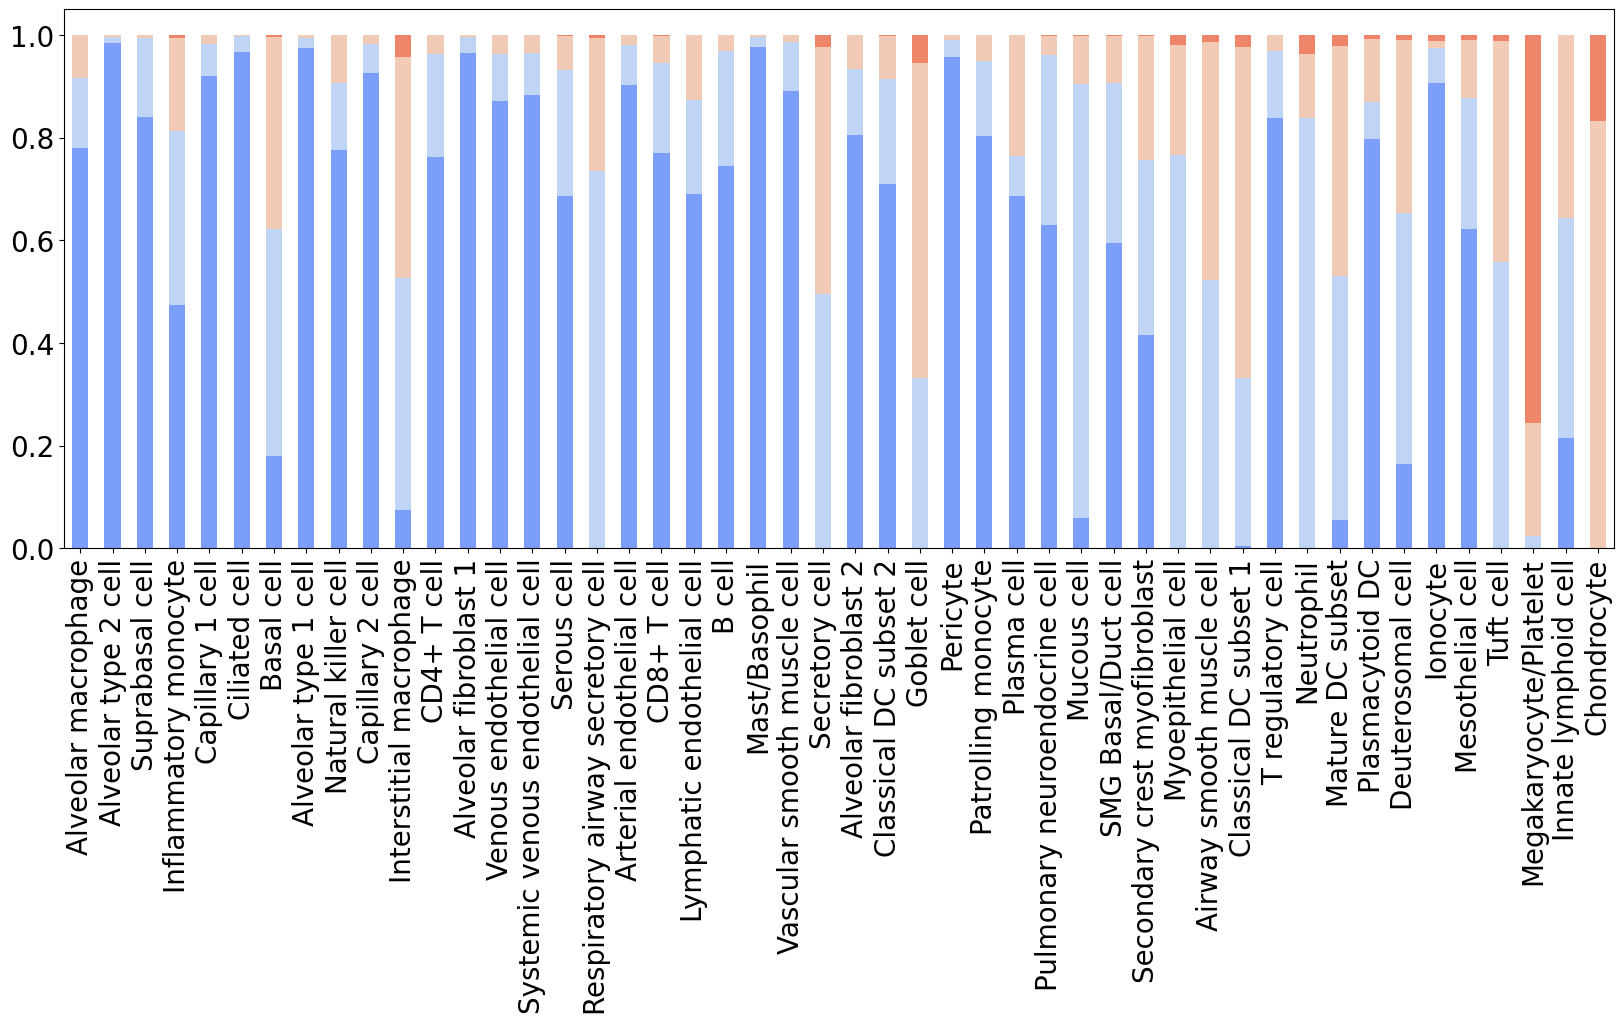

In [103]:
new_df.plot(kind='bar', stacked=True, color=colors, figsize=(20, 7), legend='lower right')
plt.tick_params(axis='x', which='major', labelsize=20)
plt.tick_params(axis='y', which='major', labelsize=20)



plt.legend(title='max_agreement', loc='lower left').set_visible(False)

In [101]:
df.groupby(['cellref_true', 'max_agreement']).count()

azimuth_pred  azimuth_score  \
cellref_true                max_agreement                                
Airway smooth muscle cell   1                         7              7   
                            2                       239            239   
                            3                       269            269   
Alveolar fibroblast 1       2                        22             22   
                            3                       168            168   
...                                                 ...            ...   
Vascular smooth muscle cell 3                       277            277   
                            4                      2599           2599   
Venous endothelial cell     2                       178            178   
                            3                       440            440   
                            4                      4158           4158   

                                           celltypist_pred  celltypist_score  \
cellref_true                max_agreement                                      
Airway smooth muscle cell   1                            7                 7   
                            2                          239               239   
                            3                          269               269   
Alveolar fibroblast 1       2                           22                22   
                            3                          168               168   
...                                                    ...               ...   
Vascular smooth muscle cell 3                          277               277   
                            4                         2599              2599   
Venous endothelial cell     2                          178               178   
                            3                          440               440   
                            4                         4158              4158   

                                           fr-match_pred  fr-match_score  \
cellref_true                max_agreement                                  
Airway smooth muscle cell   1                          7               7   
                            2                        239             239   
                            3                        269             269   
Alveolar fibroblast 1       2                         22              22   
                            3                        168             168   
...                                                  ...             ...   
Vascular smooth muscle cell 3                        277             277   
                            4                       2599            2599   
Venous endothelial cell     2                        178             178   
                            3                        440             440   
                            4                       4158            4158   

                                           scarches_pred  scarches_score  
cellref_true                max_agreement                                 
Airway smooth muscle cell   1                          7               7  
                            2                        239             239  
                            3                        269             269  
Alveolar fibroblast 1       2                         22              22  
                            3                        168             168  
...                                                  ...             ...  
Vascular smooth muscle cell 3                        277             277  
                            4                       2599            2599  
Venous endothelial cell     2                        178             178  
                            3                        440             440  
                            4                       4158            4158  

[166 rows x 8 columns]